# WEEE — İvmeölçerden MET ve Energy Expenditure Tahmini
### Çalıştırma sırası ve ölçülen süreler
### Bu sürümde giderilen sorunlar


## 0. Kurulum


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import glob, shutil, os, re, time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

zips = glob.glob('/content/drive/MyDrive/PAWS/*.zip')
shutil.unpack_archive(zips[0], '/content/weee_data')
DATA_ROOT = os.path.dirname(glob.glob('/content/weee_data/**/Study_Information.csv', recursive=True)[0])
print("DATA_ROOT =", DATA_ROOT)

# ── ANA AYARLAR ──────────────────────────────────────────────────────────────
FEATURE_SET = 'zengin'   # 'eski' | 'simetrik' | 'zengin'   (B0 üçünü kıyaslar)
WIN_A       = 4          # Bölüm A pencere uzunluğu (sn) — danışmanın tarif ettiği kurulum
MAX_OFF     = 300        # VO2 hizalamada kabul edilen en büyük sapma (sn); aşılırsa Start_Sit
# ─────────────────────────────────────────────────────────────────────────────
print(f"FEATURE_SET={FEATURE_SET} | WIN_A={WIN_A} sn | MAX_OFF={MAX_OFF} sn")

DATA_ROOT = /content/weee_data/dataset
FEATURE_SET=zengin | WIN_A=4 sn | MAX_OFF=300 sn


## 1. Sinyal yardımcıları ve feature setleri


In [18]:
def clean(x):
    """Eksik örnekleri doldur — ham sinyal MAD/ENMO için de kullanılıyor, NaN sızmamalı."""
    return np.nan_to_num(pd.Series(x,dtype='float64').interpolate(limit_direction='both').to_numpy())
def bandpass(x, fs, low, high, order=4):
    nyq=fs/2.0; high=min(high, nyq*0.95)
    b,a=butter(order,[low/nyq,high/nyq],btype='bandpass')
    return filtfilt(b,a,clean(x))
def mag3(x,y,z): return np.sqrt(x**2+y**2+z**2)
def segment_signal(sig, fs, win_sec, overlap=0.5):
    sig=np.asarray(sig); w=int(round(win_sec*fs)); step=max(1,int(round(w*(1-overlap))))
    return [sig[s:s+w] for s in range(0,len(sig)-w+1,step)]

OLD6   = ["energy","shannon_entropy","max_amplitude","max_location","min_amplitude","min_location"]
OLD_EE = ["enmo","std","rms","sma","dom_freq","spec_entropy"]
SYM_EE = ["mad", "std","rms","sma","dom_freq","spec_entropy"]
RICH   = ["mad","energy","std","rms","sma","p10","p50","p90","iqr","rmssd","zcr","autocorr1",
          "shannon_entropy","dom_freq","spec_entropy","bp_low","bp_mid","bp_high"]

def shannon_entropy(w,bins=32):
    h,_=np.histogram(w,bins=bins); p=h.astype(float); p=p[p>0]
    if p.size==0: return 0.0
    p/=p.sum(); return float(-np.sum(p*np.log2(p)))
def _spec(w,fs):
    s=np.abs(np.fft.rfft(w)); fr=np.fft.rfftfreq(len(w),1/fs)
    dom=float(fr[1:][np.argmax(s[1:])]) if len(s)>1 else 0.0
    p=s**2; tot=p.sum()+1e-12; pn=p/tot
    return dom, float(-np.sum(pn*np.log2(pn+1e-12))), p, fr, tot
def _f_old6(w):
    w=np.asarray(w,float)
    return [float(np.sum(w**2)),shannon_entropy(w),float(w.max()),int(w.argmax()),
            float(w.min()),int(w.argmin())]
def _f_ee(wbp,wraw,fs,lead):
    w=np.asarray(wbp,float); r=np.asarray(wraw,float); dom,se,_,_,_=_spec(w,fs)
    v=float(np.mean(np.maximum(r-1.0,0.0))) if lead=='enmo' else float(np.mean(np.abs(r-r.mean())))
    return [v,float(w.std()),float(np.sqrt(np.mean(w**2))),float(np.mean(np.abs(w))),dom,se]
def _f_rich(wbp,wraw,fs):
    w=np.asarray(wbp,float); r=np.asarray(wraw,float); n=len(w)
    mad=float(np.mean(np.abs(r-r.mean())))
    p10,p50,p90=np.percentile(w,[10,50,90]); dv=np.diff(w)
    rmssd=float(np.sqrt(np.mean(dv**2))) if n>1 else 0.0
    zcr=float(np.mean(np.diff(np.sign(w))!=0)) if n>1 else 0.0
    wc=w-w.mean(); den=float(np.sum(wc**2))+1e-12
    ac1=float(np.sum(wc[:-1]*wc[1:])/den) if n>1 else 0.0
    dom,se,p,fr,tot=_spec(w,fs)
    band=lambda lo,hi: float(p[(fr>=lo)&(fr<hi)].sum()/tot)
    return [mad,float(np.sum(w**2)/n),float(w.std()),float(np.sqrt(np.mean(w**2))),
            float(np.mean(np.abs(w))),float(p10),float(p50),float(p90),float(p90-p10),
            rmssd,zcr,ac1,shannon_entropy(w),dom,se,band(0.5,2),band(2,5),band(5,12)]

def cols_for(fset,kind):
    if fset=='eski':     return OLD6+(OLD_EE if kind=='E4' else [])
    if fset=='simetrik': return OLD6+SYM_EE
    return RICH
def feats_for(fset,kind,wbp,wraw,fs):
    if fset=='eski':     return _f_old6(wbp)+(_f_ee(wbp,wraw,fs,'enmo') if kind=='E4' else [])
    if fset=='simetrik': return _f_old6(wbp)+_f_ee(wbp,wraw,fs,'mad')
    return _f_rich(wbp,wraw,fs)
for f in ['eski','simetrik','zengin']:
    print(f"{f:9}: E4 {len(cols_for(f,'E4')):2} | Zephyr {len(cols_for(f,'ZEPHYR')):2} | Muse {len(cols_for(f,'MUSE')):2}")

eski     : E4 12 | Zephyr  6 | Muse  6
simetrik : E4 12 | Zephyr 12 | Muse 12
zengin   : E4 18 | Zephyr 18 | Muse 18


## 2. Aktivite aralıkları ve MET


In [19]:
ACTS=[('Sit','Start_Sit','MET_Sit'),('Stand','Start_Stand','MET_Stand'),
      ('Cycle1','Start_Cycle1','MET_Cycle1'),('Cycle2','Start_Cycle2','MET_Cycle2'),
      ('Run1','Start_Run1','MET_Run1'),('Run2','Start_Run2','MET_Run2')]
ACT_ORDER=[a for a,_,_ in ACTS]
def to_unix(s): return pd.Timestamp(str(s).strip()).tz_localize('UTC').timestamp()
def to_num(x):
    try: return float(str(x).strip())
    except: return np.nan
def activity_segments(r):
    st=[to_unix(r[c]) for _,c,_ in ACTS]; out=[]
    for i,(nm,sc,mc) in enumerate(ACTS):
        a=st[i]; nxt=st[i+1] if i+1<len(st) else a+300; b=min(nxt,a+300)
        out.append(dict(activity=nm,MET=to_num(r[mc]),start=a,end=b,valid=b>a))
    return out
SI=pd.read_csv(os.path.join(DATA_ROOT,'Study_Information.csv'))
print("özne sayısı:",len(SI))

özne sayısı: 17


## 3. Cihaz okuyucular + feature tablosu (sinyaller ve tablolar önbellekte)


In [20]:
def load_device(path,kind):
    if kind=='E4':
        raw=pd.read_csv(path,header=None); t0=float(raw.iloc[0,0]); fs=float(raw.iloc[1,0])
        d=raw.iloc[2:].reset_index(drop=True).astype(float)/64.0
        return d.iloc[:,0].values,d.iloc[:,1].values,d.iloc[:,2].values,fs,t0+np.arange(len(d))/fs
    if kind=='ZEPHYR':
        z=pd.read_csv(path)
        tt=pd.to_datetime(z['Time'],format='%d/%m/%Y %H:%M:%S.%f').dt.tz_localize('UTC').map(lambda v:v.timestamp()).values
        return z['Vertical'].values,z['Lateral'].values,z['Sagittal'].values,100.0,tt
    d=pd.read_csv(path,header=None); d.columns=['t','x','y','z']
    d=d.sort_values('t').reset_index(drop=True); tt=d['t'].values
    span=tt[-1]-tt[0]; fs=len(d)/span if span>0 else 50.0
    return d['x'].values,d['y'].values,d['z'].values,fs,tt

DEV={'E4':dict(pat='*/E4/ACC.csv',band=(0.5,12.0)),
     'ZEPHYR':dict(pat='*/ZEPHYR/*_Accel.csv',band=(0.5,20.0)),
     'MUSE':dict(pat='*/MUSE/acc.csv',band=(0.5,12.0))}
_CACHE={}; _TABLES={}
def get_signals(kind):
    if kind in _CACHE: return _CACHE[kind]
    lo,hi=DEV[kind]['band']; out=[]
    for path in sorted(glob.glob(os.path.join(DATA_ROOT,DEV[kind]['pat']))):
        pid='P%02d'%int(''.join(filter(str.isdigit,path.split(os.sep)[-3])))
        if len(SI[SI['Participant']==pid])==0: continue
        try:
            x,y,z,fs,tt=load_device(path,kind)
            x,y,z=clean(x),clean(y),clean(z)
            xb,yb,zb=bandpass(x,fs,lo,hi),bandpass(y,fs,lo,hi),bandpass(z,fs,lo,hi)
            out.append((pid,xb,yb,zb,mag3(xb,yb,zb),mag3(x,y,z),fs,tt))
        except Exception as e: print('  atlandı',pid,kind,e)
    _CACHE[kind]=out; return out

def build_table(kind,win_sec,fset):
    key=(kind,win_sec,fset)
    if key in _TABLES: return _TABLES[key].copy()
    names=cols_for(fset,kind); rows=[]
    for pid,xb,yb,zb,mbp,mraw,fs,tt in get_signals(kind):
        r=SI[SI['Participant']==pid].iloc[0]
        for s in activity_segments(r):
            if not s['valid']: continue
            m=(tt>=s['start'])&(tt<s['end'])
            wb=segment_signal(mbp[m],fs,win_sec); wr=segment_signal(mraw[m],fs,win_sec)
            for a,b in zip(wb,wr):
                if len(a)<8: continue
                row=dict(zip(names,feats_for(fset,kind,a,b,fs)))
                row.update(MET=s['MET'],activity=s['activity'],subject=pid); rows.append(row)
    t=pd.DataFrame(rows)
    t[names]=t[names].replace([np.inf,-np.inf],np.nan)
    bad=int(t[names].isna().any(axis=1).sum())
    if bad: print(f"    [{kind} {win_sec}sn/{fset}] {bad} geçersiz pencere atıldı")
    t=t.dropna(subset=names).reset_index(drop=True)
    _TABLES[key]=t; return t.copy()
print("hazır")

hazır


## 4. EE hedefi (VO2), hizalama doğrulaması, vücut kompozisyonu


In [21]:
VO2_CANDIDATES = ['VO2MasterUnit-Data.csv','DataAverage.csv']

def vo2_folder(pid):
    for fold in glob.glob(os.path.join(DATA_ROOT,'*','VO2')):
        if 'P%02d'%int(''.join(filter(str.isdigit,fold.split(os.sep)[-2])))==pid: return fold
    return None

def find_vo2(pid):
    fold=vo2_folder(pid)
    if fold is None: return None
    for name in VO2_CANDIDATES:
        p=os.path.join(fold,name)
        if os.path.exists(p): return p
    csvs=[c for c in sorted(glob.glob(os.path.join(fold,'*.csv')))
          if 'Diagnostic' not in c and 'Session' not in c and 'HeartRate' not in c]
    return csvs[0] if csvs else None

def parse_details_start(pid,ref):
    for f in glob.glob(os.path.join(DATA_ROOT,'*','VO2','Details.txt')):
        if 'P%02d'%int(''.join(filter(str.isdigit,f.split(os.sep)[-3])))!=pid: continue
        txt=open(f,errors='ignore').read()
        try:
            date=re.search(r'Workout Date:\s*(.+)',txt).group(1).strip()
            tm=re.search(r'Start Time:\s*(.+)',txt).group(1).strip()
            m=re.search(r'Time Zone:\s*(.+)',txt); tz=m.group(1).strip() if m else 'UTC'
        except AttributeError: return None
        c=[]
        for fmt in ('%d/%m/%Y %I:%M:%S %p','%m/%d/%Y %I:%M:%S %p'):
            try: c.append(pd.to_datetime(f"{date} {tm}",format=fmt).tz_localize(tz).tz_convert('UTC').timestamp())
            except Exception: pass
        if c: return min(c,key=lambda u:abs(u-ref))

def vo2_unix(v, used):
    """Zaman ekseni. DataAverage.csv mutlak duvar saati ('Time') içerir ve bu dosyalarda
    Time[s] tekrar edebilir (cihaz durdurulup yeniden başlatılmış → satır sayısı Time[s]
    aralığından fazla). Mutlak sütun varsa o kullanılır; yoksa Details.txt + Time[s].
    Aralık ayı Europe/London = GMT olduğu için yerel saat = UTC."""
    if 'Time' in v.columns:
        t=pd.to_datetime(v['Time'],errors='coerce')
        if t.notna().mean()>0.9:
            return t.dt.tz_localize('UTC').map(lambda x:x.timestamp()).values, 'mutlak Time'
    return used+v['Time[s]'].values, 'Details+Time[s]'

print("=== VO2 klasörü içeriği (hangi öznede hangi dosya var) ===")
for _,r in SI.iterrows():
    pid=r['Participant']; fold=vo2_folder(pid)
    if fold is None: print(f"  {pid}: VO2 klasörü YOK"); continue
    files=sorted(os.path.basename(x) for x in glob.glob(os.path.join(fold,'*.csv')))
    sec=find_vo2(pid)
    print(f"  {pid}: {files}  -> seçilen: {os.path.basename(sec) if sec else 'YOK'}")

print("\n=== çok oturumlu dosya kontrolü + mutlak 'Time' doğrulaması ===")
for _,r in SI.iterrows():
    pid=r['Participant']; fold=vo2_folder(pid)
    if fold is None: continue
    da=os.path.join(fold,'DataAverage.csv')
    if not os.path.exists(da): continue
    v=pd.read_csv(da); v.columns=v.columns.str.strip()
    t=v['Time[s]'].values; geri=int((np.diff(t)<0).sum())
    msg=f"  {pid}: satır {len(v):5} | Time[s] aralığı {t.max()-t.min():6.0f} sn | geri sayım {geri}"
    if 'Time' in v.columns:
        t0=pd.to_datetime(v['Time'].iloc[0])
        msg+=f" | ilk mutlak kayıt − Start_Sit = {t0.tz_localize('UTC').timestamp()-to_unix(r['Start_Sit']):+8.1f} sn"
    print(msg)
print("  (geri sayım > 0 → dosya birden fazla oturum içeriyor; mutlak Time bunu doğru çözer)")
print("  (her iki dosyası da olan öznelerde son sütun ~0 çıkmalı → UTC varsayımı doğru)\n")

EE_MAP={}; chk=[]
for _,r in SI.iterrows():
    pid=r['Participant']; path=find_vo2(pid)
    if path is None: chk.append((pid,np.nan,'VO2 yok','-')); continue
    ref=to_unix(r['Start_Sit']); start=parse_details_start(pid,ref)
    if start is None:
        used,off,durum = ref, np.nan, 'Details okunamadi'
    else:
        off=round(start-ref,1)
        if   abs(off)<=5:       used,durum = start,'ok'
        elif abs(off)<=MAX_OFF: used,durum = start,'kucuk sapma'
        else:                   used,durum = ref,  'DUZELTILDI -> Start_Sit'
    v=pd.read_csv(path); v.columns=v.columns.str.strip()
    if 'VO2[mL/min]' not in v.columns:
        chk.append((pid,off,'VO2[mL/min] kolonu yok','-')); continue
    n0=len(v)
    v=v[v['VO2[mL/min]']>0].copy()          # makale: VO2=0 satırları atılmalı
    if n0-len(v): print(f"    {pid}: {n0-len(v)} adet VO2=0 satırı atıldı")
    u,yontem = vo2_unix(v, used)
    v['unix']=u; v['ee']=v['VO2[mL/min]']/1000.0*4.84
    chk.append((pid,off,durum,yontem))
    for s in activity_segments(r):
        w=v[(v['unix']>=s['start'])&(v['unix']<s['end'])]
        EE_MAP[(pid,s['activity'])]=w['ee'].mean() if len(w) else np.nan
chk=pd.DataFrame(chk,columns=['subject','offset_sn','durum','zaman_ekseni'])
print("\n=== VO2 hizalama doğrulaması (TÜM özneler) ==="); print(chk.to_string(index=False))
print("EE etiketli segment:",sum(x==x for x in EE_MAP.values()),"/",len(EE_MAP),
      "| EE'si olan özne:",len({k[0] for k,v in EE_MAP.items() if v==v}))

ee_tab=pd.Series(EE_MAP).unstack().reindex(columns=ACT_ORDER)
print("\n=== özne × aktivite EE (kcal/dk) — Sit düşük, Run yüksek olmalı ===")
print(ee_tab.round(2).to_string())
cov=ee_tab.notna().sum(axis=1); med_rest=float(ee_tab['Sit'].median()); flags={}
def add_flag(p,msg): flags.setdefault(p,[]).append(msg)
for p in ee_tab.index:
    r=ee_tab.loc[p]
    if cov[p]<3: add_flag(p,f"yalnız {cov[p]}/6 aktivite etiketli")
    if r['Sit']==r['Sit'] and r['Sit']>2*med_rest:
        add_flag(p,f"dinlenme EE yüksek ({r['Sit']:.2f} vs kohort medyanı {med_rest:.2f})")
    for lo,hi in [('Run1','Run2'),('Cycle1','Cycle2')]:
        if r[[lo,hi]].notna().all() and r[hi]<r[lo]:
            add_flag(p,f"{hi} < {lo} ({r[hi]:.2f} < {r[lo]:.2f}) — yoğunlukla ters")
print("\naktivite kapsamı (etiketli aktivite sayısı / 6):"); print(cov.to_string())
print("\n=== EE etiket teşhisi ===")
if flags:
    for p,ms in flags.items(): print(f"  {p}: " + "; ".join(ms))
else: print("  sorun yok")

demo=pd.read_csv(glob.glob(os.path.join(DATA_ROOT,'**','Demographics.csv'),recursive=True)[0])
demo['Sex']=(demo['Gender'].astype(str).str.upper()=='M').astype(int)
demo['FFM']=demo['Weight']*(1-demo['Fat']/100.0)
DEMO=demo.set_index('Participant')[['Weight','Height','BMI','Age','Sex','FFM']]
print(f"\nDemografik tablo: {DEMO.shape[0]} özne, eksik değer {DEMO.isna().sum().sum()}")
def attach(d):
    d=d.copy(); d['EE']=[EE_MAP.get((s,a),np.nan) for s,a in zip(d['subject'],d['activity'])]
    for c in DEMO.columns: d[c]=d['subject'].map(DEMO[c])
    return d
def make_devices(win,fset):
    return {'E4_bilek':attach(build_table('E4',win,fset)),
            'Zephyr_gogus':attach(build_table('ZEPHYR',win,fset)),
            'Muse_kafa':attach(build_table('MUSE',win,fset))}

=== VO2 klasörü içeriği (hangi öznede hangi dosya var) ===
  P01: ['DataAverage.csv', 'HeartRateMonitor-Data.csv', 'SessionDiagnostics.csv', 'VO2 Master 741Diagnostics.csv', 'VO2MasterUnit-Data.csv']  -> seçilen: VO2MasterUnit-Data.csv
  P02: ['DataAverage.csv']  -> seçilen: DataAverage.csv
  P03: ['DataAverage.csv']  -> seçilen: DataAverage.csv
  P04: ['DataAverage.csv', 'HeartRateMonitor-Data.csv', 'SessionDiagnostics.csv', 'VO2 Master 741Diagnostics.csv', 'VO2MasterUnit-Data.csv']  -> seçilen: VO2MasterUnit-Data.csv
  P05: ['DataAverage.csv', 'HeartRateMonitor-Data.csv', 'SessionDiagnostics.csv', 'VO2 Master 741Diagnostics.csv', 'VO2MasterUnit-Data.csv']  -> seçilen: VO2MasterUnit-Data.csv
  P06: ['DataAverage.csv', 'HeartRateMonitor-Data.csv', 'SessionDiagnostics.csv', 'VO2 Master 741Diagnostics.csv', 'VO2MasterUnit-Data.csv']  -> seçilen: VO2MasterUnit-Data.csv
  P07: ['DataAverage.csv', 'HeartRateMonitor-Data.csv', 'SessionDiagnostics.csv', 'VO2 Master 741Diagnostics.csv', 'VO2Ma

In [22]:
rows=[]
for _,r in SI.iterrows():
    pid=r['Participant']; path=find_vo2(pid)
    if path is None: continue
    ref=to_unix(r['Start_Sit']); st=parse_details_start(pid,ref)
    used = st if (st is not None and abs(st-ref)<=MAX_OFF) else ref
    v=pd.read_csv(path); v.columns=v.columns.str.strip()
    v=v[v['VO2[mL/min]']>0].copy(); v['unix']=used+v['Time[s]']
    for s in activity_segments(r):
        w=v[(v['unix']>=s['start'])&(v['unix']<s['end'])]
        rows.append(dict(subject=pid, activity=s['activity'], n=len(w)))
cnt=pd.DataFrame(rows).pivot(index='subject',columns='activity',values='n').reindex(columns=ACT_ORDER)
print("=== her segmentin EE ortalaması kaç geçerli VO2 örneğinden hesaplandı ===")
print(cnt.to_string())

=== her segmentin EE ortalaması kaç geçerli VO2 örneğinden hesaplandı ===
activity  Sit  Stand  Cycle1  Cycle2  Run1  Run2
subject                                         
P01        73     84      92      97   126   142
P02       312    489     300       0     0     0
P03       297    428       0       0     0     0
P04       122    121     107     120   149    38
P05        95     96     109     121   135    48
P06        54     53     102     130   147    95
P07        72     81      71      89   128    32
P08        77     81      85      91   108    42
P09        67     57      85     122    53     8
P10        55    111       0       0     0     0
P11        81     92     123     142   167    11
P12       595    600     519       0     0     0
P13        82     85     100     129   156   110
P14        99      0       0       0     0     0
P15        85     88      83     103    36     0
P16       324    300     300     179     0     0
P17        50     64     105     119   130  

In [23]:
for pid in ['P01','P12','P02','P03','P16']:
    p=find_vo2(pid)
    if p is None: continue
    v=pd.read_csv(p); v.columns=v.columns.str.strip()
    t=v['Time[s]'].values
    dt=np.median(np.diff(t))
    vv=v[(v['VO2[mL/min]']>0)&(v['VO2[mL/kg/min]']>0)]
    w_ima=(vv['VO2[mL/min]']/vv['VO2[mL/kg/min]']).median()
    w_dem=DEMO.loc[pid,'Weight'] if pid in DEMO.index else np.nan
    print(f"{pid} | {os.path.basename(p):24} | Time[s] adım {dt:6.3f} sn | "
          f"toplam süre {t.max():7.1f} sn | satır {len(v):5} | "
          f"VO2 mL/kg/dk medyan {vv['VO2[mL/kg/min]'].median():5.2f} | "
          f"ima edilen kilo {w_ima:5.1f} vs demografik {w_dem:5.1f}")
print()
print(pd.read_csv(find_vo2('P12')).head(8).to_string())

P01 | VO2MasterUnit-Data.csv   | Time[s] adım  2.780 sn | toplam süre  1800.1 sn | satır   639 | VO2 mL/kg/dk medyan 10.51 | ima edilen kilo  69.0 vs demografik  70.6
P12 | DataAverage.csv          | Time[s] adım  1.000 sn | toplam süre  1056.0 sn | satır  1962 | VO2 mL/kg/dk medyan 10.99 | ima edilen kilo  63.0 vs demografik  63.6
P02 | DataAverage.csv          | Time[s] adım  1.000 sn | toplam süre  1544.0 sn | satır  2148 | VO2 mL/kg/dk medyan 11.40 | ima edilen kilo  75.0 vs demografik  77.0
P03 | DataAverage.csv          | Time[s] adım  1.000 sn | toplam süre  1366.0 sn | satır  1992 | VO2 mL/kg/dk medyan  5.18 | ima edilen kilo  61.0 vs demografik  61.0
P16 | DataAverage.csv          | Time[s] adım  1.000 sn | toplam süre  1304.0 sn | satır  1541 | VO2 mL/kg/dk medyan  6.85 | ima edilen kilo  73.1 vs demografik  73.1

   Time[s] Time[hh:mm:ss]  VO2[mL/kg/min]  VO2[mL/min]  HR[bpm]  Rf[bpm]  Tv[L]  Ve[L/min]  Ve/VO2  FeO2[%]  Pressure[hPa]  Temp[C]  HUM[%RH]   RR[ms]              

## 5. Modelleme çekirdeği


In [24]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingRegressor
from scipy.stats import spearmanr
try:
    from xgboost import XGBRegressor; HAS_XGB=True
except Exception:
    HAS_XGB=False; print("xgboost yok — diğer ailelerle devam")

HEAVY_MAX_N=6000
def model_zoo(n=0):
    z={'Linear(Ridge)'   : lambda: make_pipeline(StandardScaler(),Ridge(alpha=1.0)),
       'RandomForest'    : lambda: RandomForestRegressor(n_estimators=200,random_state=0,n_jobs=-1),
       'GradientBoosting': lambda: HistGradientBoostingRegressor(max_iter=400,max_depth=5,
                                       learning_rate=0.05,random_state=0)}
    if HAS_XGB:
        z['XGBoost']=lambda: XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,
                             subsample=0.9,colsample_bytree=0.9,random_state=0,n_jobs=-1)
    if 0<n<=HEAVY_MAX_N:
        z['ANN(MLP)']=lambda: make_pipeline(StandardScaler(),
                        MLPRegressor(hidden_layer_sizes=(64,32),max_iter=600,early_stopping=True,
                        n_iter_no_change=10,random_state=0))
        z['SVR(RBF)']=lambda: make_pipeline(StandardScaler(),SVR(C=10,gamma='scale',epsilon=0.1))
    return z
def ALL_MODELS(): return model_zoo(1)      # tam havuz (ANN + SVR dahil) — tekil model çağırmak için
def FAST():
    return (lambda: XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.9,
            colsample_bytree=0.9,random_state=0,n_jobs=-1)) if HAS_XGB else \
           (lambda: HistGradientBoostingRegressor(max_iter=300,max_depth=5,learning_rate=0.05,random_state=0))
def CLF(): return RandomForestClassifier(n_estimators=300,random_state=0,n_jobs=-1)

META={'MET','EE','activity','subject','Weight','Height','BMI','Age','Sex','FFM'}
def feat_cols(d,extra=()):
    return [c for c in d.columns if c not in META and pd.api.types.is_numeric_dtype(d[c])]+list(extra)

def smape(y,p):
    """Simetrik ortalama mutlak yüzde hata (%). MET regresyonunda literatürün standart metriği;
    WEEE üzerinde yayınlanmış değerlerle kıyas yapmayı sağlar."""
    y=np.asarray(y,float); p=np.asarray(p,float)
    return float(np.mean(2*np.abs(p-y)/(np.abs(y)+np.abs(p)+1e-12))*100)

def seg_frame(subject,activity,y,pred):
    d=pd.DataFrame({'subject':np.asarray(subject),'activity':np.asarray(activity),
                    'y':np.asarray(y,float),'p':np.asarray(pred,float)}).dropna()
    return d.groupby(['subject','activity']).agg(y=('y','first'),p=('p','mean')).reset_index(), d
def seg_metrics(subject,activity,y,pred,base_pred=None):
    seg,d=seg_frame(subject,activity,y,pred)
    yy,pp=seg['y'].values,seg['p'].values
    bb=np.full_like(yy,d['y'].mean()) if base_pred is None else seg_frame(subject,activity,y,base_pred)[0]['p'].values
    return dict(MAE=mean_absolute_error(yy,pp),RMSE=mean_squared_error(yy,pp)**0.5,
                R2=r2_score(yy,pp),Spearman=spearmanr(pp,yy)[0],SMAPE=smape(yy,pp),
                MAE_base=mean_absolute_error(yy,bb),n=len(seg),subj=d['subject'].nunique())

def _prep(d,target,extra,norm_col):
    """Hedef + kullanılan ek sütunlarda eksik değer olan satırları düş (NaN kabul etmeyen modeller için)."""
    need=[target]+[c for c in extra]+([norm_col] if norm_col else [])
    return d.dropna(subset=need).reset_index(drop=True)

def loso_single(d,target,model_fn,extra=(),norm_col=None,return_pred=False):
    d=_prep(d,target,extra,norm_col); cols=feat_cols(d,extra)
    y=d[target].values; yt=y/d[norm_col].values if norm_col else y
    yh=np.full(len(d),np.nan); yb=np.full(len(d),np.nan)
    for tr,te in LeaveOneGroupOut().split(d[cols],yt,d['subject']):
        m=model_fn(); m.fit(d[cols].iloc[tr],yt[tr]); p=m.predict(d[cols].iloc[te])
        yh[te]=p*d[norm_col].values[te] if norm_col else p
        yb[te]=y[tr].mean()
    ov=seg_metrics(d['subject'],d['activity'],y,yh,yb)
    return (ov,d,yh) if return_pred else ov

def loso_twostage(d,target,model_fn,extra=(),norm_col=None,oracle=False):
    """Branched/hierarchical: aktivite sınıflandır → aktiviteye özel regresyon."""
    d=_prep(d,target,extra,norm_col); cols=feat_cols(d,extra)
    y=d[target].values; yt=y/d[norm_col].values if norm_col else y
    yh=np.full(len(d),np.nan); yb=np.full(len(d),np.nan); accs=[]
    for tr,te in LeaveOneGroupOut().split(d[cols],yt,d['subject']):
        yb[te]=y[tr].mean()
        Xtr,Xte=d[cols].iloc[tr],d[cols].iloc[te]; atr=d['activity'].iloc[tr].values
        if oracle: route=d['activity'].iloc[te].values
        else:
            c=CLF(); c.fit(Xtr,atr); route=c.predict(Xte)
            accs.append(accuracy_score(d['activity'].iloc[te].values,route))
        g=model_fn(); g.fit(Xtr,yt[tr]); pred=g.predict(Xte)
        for a in np.unique(route):
            s=(atr==a)
            if s.sum()>=20:
                r=model_fn(); r.fit(Xtr[s],yt[tr][s]); sel=(route==a); pred[sel]=r.predict(Xte[sel])
        yh[te]=pred*d[norm_col].values[te] if norm_col else pred
    ov=seg_metrics(d['subject'],d['activity'],y,yh,yb)
    ov['clf_acc']=round(float(np.mean(accs)),3) if accs else 1.0
    return ov

def bootstrap_ci(seg,B=2000,seed=0):
    """Özne bazlı bootstrap — küçük fold sayısında 'en iyi model' iddiasının gürbüzlüğü."""
    rng=np.random.default_rng(seed)
    groups={s:g[['y','p']].values for s,g in seg.groupby('subject')}
    keys=list(groups); vals=[]
    for _ in range(B):
        arr=np.vstack([groups[k] for k in rng.choice(keys,len(keys),replace=True)])
        vals.append(np.mean(np.abs(arr[:,1]-arr[:,0])))
    return float(np.percentile(vals,2.5)), float(np.percentile(vals,97.5))

def R(tag,dev,ov,**kw):
    return dict(**kw,model=tag,cihaz=dev,**{k:round(ov[k],3) for k in ['MAE','RMSE','R2','Spearman','SMAPE']},
                MAE_base=round(ov['MAE_base'],3),n=ov['n'],subj=ov['subj'])
def run_grid(devices,target,zoo_filter=None,**kw):
    rows=[]
    for dev,t in devices.items():
        zoo=model_zoo(int(t[target].notna().sum()))
        if zoo_filter: zoo={k:v for k,v in zoo.items() if k in zoo_filter}
        for name,fn in zoo.items():
            rows.append(R(name,dev,loso_single(t,target,fn,**kw)))
    return pd.DataFrame(rows)
COLS=['cihaz','model','MAE','RMSE','R2','Spearman','SMAPE','MAE_base','n','subj']
print("hazır | XGBoost:",HAS_XGB)

hazır | XGBoost: True


## 6. Tabloları kur + **uçuş öncesi kontrol**


In [25]:
t0=time.time()
DEV_A=make_devices(WIN_A,FEATURE_SET)
print(f"tablolar kuruldu ({time.time()-t0:.0f} sn)\n")
def preflight(devs):
    ok=True
    for k,t in devs.items():
        fc=feat_cols(t)
        nan=int(t[fc].isna().sum().sum()); inf=int(np.isinf(t[fc].to_numpy()).sum())
        dnan=int(t[list(DEMO.columns)].isna().sum().sum())
        flag='' if (nan==0 and inf==0) else '   <-- SORUN'
        print(f"  {k:14} satır {len(t):6} | feature {len(fc):2} | NaN {nan} | inf {inf} | "
              f"demo-NaN {dnan} | özne {t['subject'].nunique():2} | EE'li satır {int(t['EE'].notna().sum()):5}{flag}")
        if nan or inf: ok=False
    # EE etiketi olduğu halde modele giremeyen özneler (o segmentlerde ivmeölçer penceresi yok)
    ee_lbl={k[0] for k,v in EE_MAP.items() if v==v}
    for k,t in devs.items():
        inmod=set(t.loc[t['EE'].notna(),'subject'])
        drop=sorted(ee_lbl-inmod)
        if drop:
            print(f"  NOT [{k}] EE etiketi olup modele girmeyen özne: {drop} "
                  f"→ modelleme {len(inmod)} özne ile (etiketli {len(ee_lbl)})")
    print("\nSONUÇ:", "temiz — modeller koşulabilir." if ok else "NaN/inf VAR — modeller çökecek!")
    return ok
preflight(DEV_A)

tablolar kuruldu (87 sn)

  E4_bilek       satır  13910 | feature 18 | NaN 0 | inf 0 | demo-NaN 0 | özne 17 | EE'li satır 13016
  Zephyr_gogus   satır  13902 | feature 18 | NaN 0 | inf 0 | demo-NaN 0 | özne 17 | EE'li satır 13008
  Muse_kafa      satır  12130 | feature 18 | NaN 0 | inf 0 | demo-NaN 0 | özne 16 | EE'li satır 11240
  NOT [E4_bilek] EE etiketi olup modele girmeyen özne: ['P10'] → modelleme 16 özne ile (etiketli 17)
  NOT [Zephyr_gogus] EE etiketi olup modele girmeyen özne: ['P10'] → modelleme 16 özne ile (etiketli 17)
  NOT [Muse_kafa] EE etiketi olup modele girmeyen özne: ['P02', 'P10'] → modelleme 15 özne ile (etiketli 17)

SONUÇ: temiz — modeller koşulabilir.


True

# BÖLÜM A — İstenen çekirdek çalışma


## A1. MET tahmini — cihaz × model *(≈47 dk)*


In [26]:
t0=time.time()
metA=run_grid(DEV_A,'MET')
print(f"=== A1 · MET — LOSO, segment bazlı ({WIN_A} sn, {FEATURE_SET}) ===")
print(metA.sort_values(['cihaz','MAE'])[COLS].to_string(index=False))
print(f"\n({time.time()-t0:.0f} sn)")

=== A1 · MET — LOSO, segment bazlı (4 sn, zengin) ===
       cihaz            model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
    E4_bilek          XGBoost 2.031 2.701 0.807     0.824 30.837     5.451 95    17
    E4_bilek GradientBoosting 2.051 2.679 0.810     0.828 30.915     5.451 95    17
    E4_bilek     RandomForest 2.055 2.700 0.807     0.835 31.779     5.451 95    17
    E4_bilek    Linear(Ridge) 3.220 3.821 0.614     0.695 52.978     5.451 95    17
   Muse_kafa     RandomForest 1.933 2.601 0.832     0.863 27.760     5.738 83    16
   Muse_kafa          XGBoost 1.933 2.635 0.827     0.849 28.521     5.738 83    16
   Muse_kafa GradientBoosting 1.948 2.662 0.823     0.847 27.812     5.738 83    16
   Muse_kafa    Linear(Ridge) 2.786 3.456 0.703     0.748 48.648     5.738 83    16
Zephyr_gogus          XGBoost 1.888 2.600 0.821     0.854 30.318     5.451 95    17
Zephyr_gogus GradientBoosting 1.898 2.622 0.818     0.854 30.382     5.451 95    17
Zephyr_gogus     Rando

## A2. EE tahmini — cihaz × model *(≈29 dk)*


In [27]:
t0=time.time()
eeA=run_grid(DEV_A,'EE')
print(f"=== A2 · EE (kcal/dk) — LOSO, segment bazlı ({WIN_A} sn, {FEATURE_SET}) ===")
print(eeA.sort_values(['cihaz','MAE'])[COLS].to_string(index=False))
print(f"\n({time.time()-t0:.0f} sn)")

=== A2 · EE (kcal/dk) — LOSO, segment bazlı (4 sn, zengin) ===
       cihaz            model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
    E4_bilek GradientBoosting 0.948 1.288 0.776     0.889 24.645     2.329 89    16
    E4_bilek          XGBoost 0.959 1.309 0.769     0.887 24.856     2.329 89    16
    E4_bilek     RandomForest 0.980 1.317 0.766     0.883 25.663     2.329 89    16
    E4_bilek    Linear(Ridge) 1.199 1.531 0.684     0.860 36.016     2.329 89    16
   Muse_kafa    Linear(Ridge) 0.971 1.419 0.734     0.860 26.116     2.354 77    15
   Muse_kafa GradientBoosting 1.004 1.540 0.686     0.846 24.203     2.354 77    15
   Muse_kafa     RandomForest 1.019 1.534 0.689     0.847 24.727     2.354 77    15
   Muse_kafa          XGBoost 1.027 1.552 0.681     0.839 25.139     2.354 77    15
Zephyr_gogus          XGBoost 0.883 1.292 0.775     0.885 23.393     2.329 89    16
Zephyr_gogus     RandomForest 0.894 1.292 0.775     0.890 23.732     2.329 89    16
Zephyr_gogus 

## A3. Adil cihaz karşılaştırması *(≈30 dk)*


In [28]:
t0=time.time()
common=set.intersection(*[set(zip(d['subject'],d['activity'])) for d in DEV_A.values()])
def restrict(d):
    k=list(zip(d['subject'],d['activity'])); return d[[x in common for x in k]].reset_index(drop=True)
DEV_AC={k:restrict(v) for k,v in DEV_A.items()}
print("ortak segment:",len(common))
if FEATURE_SET=='eski': print("UYARI: 'eski' set → feature sayıları eşit değil, karşılaştırma kısmen adil değil.")
for tgt in ['MET','EE']:
    tb=run_grid(DEV_AC,tgt)
    print(f"\n=== A3 · {tgt} — ortak segmentler ===")
    print(tb.sort_values(['cihaz','MAE'])[COLS].to_string(index=False))
    print("\ncihaz ortalaması (MAE):"); print(tb.groupby('cihaz')['MAE'].mean().round(3).to_string())
print(f"\n({time.time()-t0:.0f} sn)")

ortak segment: 83

=== A3 · MET — ortak segmentler ===
       cihaz            model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
    E4_bilek GradientBoosting 2.078 2.763 0.810     0.822 30.535     5.723 83    16
    E4_bilek          XGBoost 2.113 2.810 0.803     0.814 31.113     5.723 83    16
    E4_bilek     RandomForest 2.137 2.824 0.801     0.821 32.001     5.723 83    16
    E4_bilek    Linear(Ridge) 3.311 3.916 0.618     0.690 55.016     5.723 83    16
   Muse_kafa     RandomForest 1.933 2.601 0.832     0.863 27.760     5.738 83    16
   Muse_kafa          XGBoost 1.933 2.635 0.827     0.849 28.521     5.738 83    16
   Muse_kafa GradientBoosting 1.948 2.662 0.823     0.847 27.812     5.738 83    16
   Muse_kafa    Linear(Ridge) 2.786 3.456 0.703     0.748 48.648     5.738 83    16
Zephyr_gogus GradientBoosting 1.899 2.649 0.825     0.847 29.442     5.723 83    16
Zephyr_gogus          XGBoost 1.937 2.696 0.819     0.844 29.967     5.723 83    16
Zephyr_gogus     Rand

## A4. En iyi EE kurulumu — Bland–Altman + bootstrap CI


En iyi: Zephyr_gogus · XGBoost
  MAE=0.883  (%95 bootstrap CI 0.680–1.105)   baseline=2.329
  bias=+0.055 kcal/dk | %95 LoA=[-2.489,+2.600] | Lin CCC=0.870 | MAPE=27.0%
  Yorum: bias≈0 → grup düzeyinde kalibrasyon iyi; LoA genişliği → bireysel kesinlik sınırlı.
  (MAPE düşük-EE segmentlerinde şişer; bias+LoA+CCC daha bilgilendirici.)


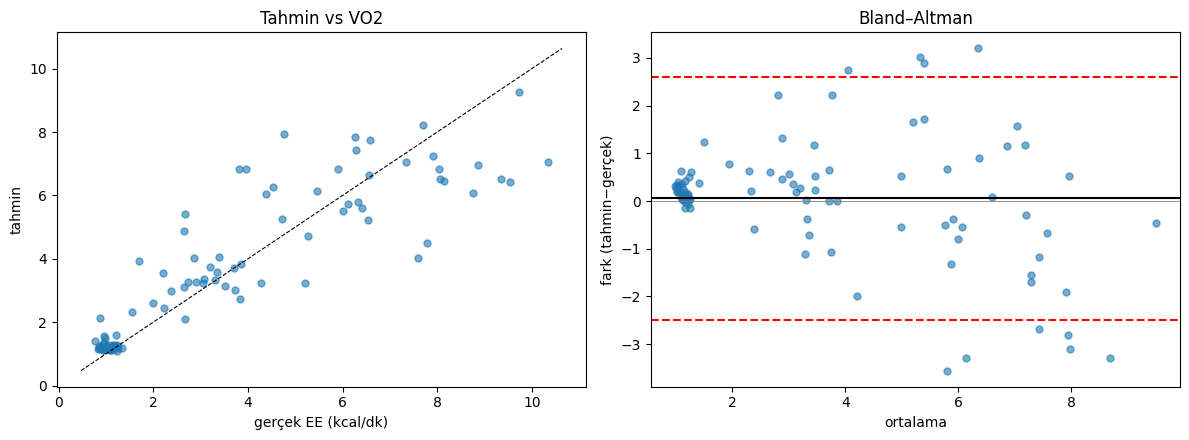


aktivite bazında bias (kcal/dk):
           mean    std  count
activity                     
Cycle1    0.265  0.801     15
Cycle2   -0.221  1.283     15
Run1     -0.090  1.895     14
Run2     -0.111  2.218     14
Sit       0.214  0.239     16
Stand     0.244  0.320     15

özne bazında ortalama mutlak hata:
subject
P02    1.752
P03    1.594
P06    1.350
P11    1.300
P15    1.115
P12    0.905
P08    0.810
P17    0.707
P13    0.670
P05    0.643
P14    0.615
P09    0.586
P16    0.574
P07    0.432
P01    0.421
P04    0.419


In [29]:
best=eeA.sort_values('MAE').iloc[0]
ov,d,yh=loso_single(DEV_A[best['cihaz']],'EE',ALL_MODELS()[best['model']],return_pred=True)
seg,_=seg_frame(d['subject'],d['activity'],d['EE'].values,yh)
lo,hi=bootstrap_ci(seg)
diff=seg['p']-seg['y']; mn=(seg['p']+seg['y'])/2
bias=diff.mean(); sd=diff.std(ddof=1); loA,hiA=bias-1.96*sd,bias+1.96*sd
sx,sy=seg['p'].std(ddof=0),seg['y'].std(ddof=0); rr=np.corrcoef(seg['p'],seg['y'])[0,1]
ccc=2*rr*sx*sy/(sx**2+sy**2+(seg['p'].mean()-seg['y'].mean())**2)
print(f"En iyi: {best['cihaz']} · {best['model']}")
print(f"  MAE={ov['MAE']:.3f}  (%95 bootstrap CI {lo:.3f}–{hi:.3f})   baseline={ov['MAE_base']:.3f}")
print(f"  bias={bias:+.3f} kcal/dk | %95 LoA=[{loA:+.3f},{hiA:+.3f}] | Lin CCC={ccc:.3f} | "
      f"MAPE={float((diff.abs()/seg['y']).mean()*100):.1f}%")
print("  Yorum: bias≈0 → grup düzeyinde kalibrasyon iyi; LoA genişliği → bireysel kesinlik sınırlı.")
print("  (MAPE düşük-EE segmentlerinde şişer; bias+LoA+CCC daha bilgilendirici.)")
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
ax[0].scatter(seg['y'],seg['p'],s=25,alpha=.6); L=[seg['y'].min()-.3,seg['y'].max()+.3]
ax[0].plot(L,L,'k--',lw=.8); ax[0].set_xlabel('gerçek EE (kcal/dk)'); ax[0].set_ylabel('tahmin')
ax[0].set_title('Tahmin vs VO2')
ax[1].scatter(mn,diff,s=25,alpha=.6); ax[1].axhline(bias,color='k'); ax[1].axhline(0,color='gray',lw=.6)
ax[1].axhline(hiA,color='r',ls='--'); ax[1].axhline(loA,color='r',ls='--')
ax[1].set_xlabel('ortalama'); ax[1].set_ylabel('fark (tahmin−gerçek)'); ax[1].set_title('Bland–Altman')
plt.tight_layout(); plt.show()
print("\naktivite bazında bias (kcal/dk):")
print(seg.assign(f=seg['p']-seg['y']).groupby('activity')['f'].agg(['mean','std','count']).round(3).to_string())
print("\nözne bazında ortalama mutlak hata:")
print(seg.assign(e=(seg['p']-seg['y']).abs()).groupby('subject')['e'].mean().round(3).sort_values(ascending=False).to_string())

# BÖLÜM B — Literatür temelli kademeli iyileştirmeler
## B0. Feature setinin etkisi (eski / simetrik / zengin) *(≈5 dk)*


In [30]:
t0=time.time(); rows=[]
for fs_name in ['eski','simetrik','zengin']:
    devs=make_devices(WIN_A,fs_name)
    for tgt in ['MET','EE']:
        for dev,t in devs.items():
            rows.append(R('GB',dev,loso_single(t,tgt,FAST()),hedef=tgt,fset=fs_name,
                          nfeat=len(feat_cols(t))))
    print(f"  {fs_name} tamam ({time.time()-t0:.0f} sn)")
fsT=pd.DataFrame(rows)
print("\n=== B0 · feature seti karşılaştırması ===")
for tgt in ['MET','EE']:
    print(f"\n--- {tgt} ---")
    print(fsT[fsT.hedef==tgt][['fset','cihaz','nfeat','MAE','RMSE','R2','Spearman']]
          .sort_values(['cihaz','fset']).to_string(index=False))
print("\nfeature seti ortalaması (MAE):")
print(fsT.pivot_table(index='fset',columns='hedef',values='MAE').round(3).to_string())

  eski tamam (76 sn)
  simetrik tamam (177 sn)
  zengin tamam (304 sn)

=== B0 · feature seti karşılaştırması ===

--- MET ---
    fset        cihaz  nfeat   MAE  RMSE    R2  Spearman
    eski     E4_bilek     12 2.167 2.832 0.788     0.818
simetrik     E4_bilek     12 2.127 2.730 0.803     0.821
  zengin     E4_bilek     18 2.037 2.697 0.808     0.824
    eski    Muse_kafa      6 2.178 2.793 0.806     0.784
simetrik    Muse_kafa     12 1.968 2.661 0.824     0.841
  zengin    Muse_kafa     18 1.926 2.626 0.828     0.850
    eski Zephyr_gogus      6 2.394 3.086 0.748     0.744
simetrik Zephyr_gogus     12 1.934 2.658 0.813     0.850
  zengin Zephyr_gogus     18 1.885 2.597 0.821     0.854

--- EE ---
    fset        cihaz  nfeat   MAE  RMSE    R2  Spearman
    eski     E4_bilek     12 0.989 1.345 0.756     0.880
simetrik     E4_bilek     12 0.978 1.312 0.768     0.883
  zengin     E4_bilek     18 0.958 1.306 0.770     0.888
    eski    Muse_kafa      6 0.991 1.494 0.705     0.856
simetr

## B1. Pencere uzunluğu (4 / 30 / 60 sn) *(≈5 dk)*


In [31]:
t0=time.time(); WINDOWS=[4,30,60]; rows=[]
for win in WINDOWS:
    devs=make_devices(win,'zengin')
    for tgt in ['MET','EE']:
        for dev,t in devs.items():
            rows.append(R('GB',dev,loso_single(t,tgt,FAST()),hedef=tgt,pencere=win))
    print(f"  {win} sn tamam ({time.time()-t0:.0f} sn)")
winT=pd.DataFrame(rows)
print("\n=== B1 · pencere uzunluğu ===")
for tgt in ['MET','EE']:
    print(f"\n--- {tgt} ---")
    print(winT[winT.hedef==tgt][['pencere','cihaz','MAE','RMSE','R2','Spearman','MAE_base','n']]
          .sort_values(['cihaz','pencere']).to_string(index=False))
print("\npencere ortalaması (MAE):")
print(winT.pivot_table(index='pencere',columns='hedef',values='MAE').round(3).to_string())
# Pencere seçimi: MET (~birimsiz, 1.5-2.5) ve EE (kcal/dk, ~0.8-0.9) farklı ölçeklerde olduğu için
# ham MAE ortalaması MET'e göre şekillenirdi. Bu yüzden her satır kendi fold-içi baseline'ına
# normalize edilip (MAE/MAE_base) öyle ortalanır — ölçekten bağımsız, hedefler eşit ağırlıklı.
winT['MAE_norm']=winT['MAE']/winT['MAE_base']
sel=winT.pivot_table(index='pencere',columns='hedef',values='MAE_norm').round(4)
sel['ortalama']=sel.mean(axis=1).round(4)
print("\nnormalize MAE (MAE / baseline) — düşük iyi:")
print(sel.to_string())
BEST_WIN=int(sel['ortalama'].idxmin())
print("\nSeçilen ortak pencere:",BEST_WIN,"sn")

print("\n=== hedef bazında en iyi pencere (raporlanmalı) ===")
raw=winT.groupby(['hedef','pencere'])['MAE'].mean().reset_index()
for tgt in ['MET','EE']:
    s=raw[raw.hedef==tgt].sort_values('MAE')
    b=s.iloc[0]; c=s[s.pencere==BEST_WIN].iloc[0]
    print(f"  {tgt}: en iyi {int(b['pencere']):2} sn (MAE {b['MAE']:.3f}) | "
          f"ortak koşum {BEST_WIN} sn (MAE {c['MAE']:.3f}) | maliyet {c['MAE']-b['MAE']:+.3f}")
print("  → İki hedefin optimal penceresi farklıysa bu maliyet raporda açıkça belirtilmelidir;")
print("    bootstrap CI genişliğiyle kıyaslayın (küçükse pratikte önemsizdir).")
DEVICES=make_devices(BEST_WIN,'zengin')
preflight(DEVICES)

  4 sn tamam (123 sn)
  30 sn tamam (212 sn)
  60 sn tamam (294 sn)

=== B1 · pencere uzunluğu ===

--- MET ---
 pencere        cihaz   MAE  RMSE    R2  Spearman  MAE_base  n
       4     E4_bilek 2.037 2.697 0.808     0.824     5.451 95
      30     E4_bilek 1.974 2.654 0.814     0.838     5.450 95
      60     E4_bilek 1.906 2.700 0.807     0.817     5.449 95
       4    Muse_kafa 1.926 2.626 0.828     0.850     5.738 83
      30    Muse_kafa 1.911 2.683 0.821     0.839     5.740 83
      60    Muse_kafa 1.702 2.567 0.835     0.860     5.720 82
       4 Zephyr_gogus 1.885 2.597 0.821     0.854     5.451 95
      30 Zephyr_gogus 1.652 2.486 0.836     0.874     5.450 95
      60 Zephyr_gogus 1.488 2.289 0.861     0.882     5.450 95

--- EE ---
 pencere        cihaz   MAE  RMSE    R2  Spearman  MAE_base  n
       4     E4_bilek 0.958 1.306 0.770     0.888     2.329 89
      30     E4_bilek 0.851 1.152 0.821     0.894     2.330 89
      60     E4_bilek 0.907 1.248 0.790     0.881     2.3

True

## B1b. Seçilen pencerede **tam model havuzu** *(hızlı)*


In [32]:
for tgt in ['MET','EE']:
    tb=run_grid(DEVICES,tgt)
    print(f"=== B1b · {tgt} — tam model havuzu ({BEST_WIN} sn) ===")
    print(tb.sort_values(['cihaz','MAE'])[COLS].to_string(index=False))
    print("\nmodel ortalaması (MAE):")
    print(tb.groupby('model')['MAE'].mean().round(3).sort_values().to_string())
    print("\ncihaz ortalaması (MAE):")
    print(tb.groupby('cihaz')['MAE'].mean().round(3).sort_values().to_string(),"\n")

=== B1b · MET — tam model havuzu (60 sn) ===
       cihaz            model   MAE  RMSE    R2  Spearman  SMAPE  MAE_base  n  subj
    E4_bilek          XGBoost 1.902 2.699 0.807     0.818 23.701     5.449 95    17
    E4_bilek GradientBoosting 1.918 2.695 0.808     0.827 24.106     5.449 95    17
    E4_bilek     RandomForest 2.041 2.837 0.787     0.795 25.144     5.449 95    17
    E4_bilek         ANN(MLP) 2.140 2.841 0.786     0.825 38.309     5.449 95    17
    E4_bilek         SVR(RBF) 2.291 2.968 0.767     0.793 39.720     5.449 95    17
    E4_bilek    Linear(Ridge) 2.857 3.485 0.679     0.723 49.699     5.449 95    17
   Muse_kafa         SVR(RBF) 1.597 2.406 0.855     0.866 20.859     5.720 82    16
   Muse_kafa         ANN(MLP) 1.650 2.456 0.849     0.865 25.372     5.720 82    16
   Muse_kafa          XGBoost 1.703 2.568 0.835     0.861 18.753     5.720 82    16
   Muse_kafa     RandomForest 1.823 2.750 0.811     0.832 19.679     5.720 82    16
   Muse_kafa GradientBoosting 1

### B1c. Hangi feature'lar sürüyor? (LOSO ortalamalı önem)


=== MET — feature önemi (Zephyr, 60 sn, LOSO ortalaması) ===
     feature   onem    std
         sma 0.4704 0.1153
         p50 0.2431 0.1157
         iqr 0.0676 0.0261
     bp_high 0.0512 0.0116
      bp_mid 0.0461 0.0092
         p90 0.0223 0.0115
         p10 0.0191 0.0167
      bp_low 0.0117 0.0012
       rmssd 0.0095 0.0015
spec_entropy 0.0094 0.0011 

=== EE — feature önemi (Zephyr, 60 sn, LOSO ortalaması) ===
feature   onem    std
    sma 0.3317 0.0967
    iqr 0.1949 0.0649
    p90 0.0937 0.0224
    std 0.0702 0.0647
    mad 0.0508 0.0198
  rmssd 0.0440 0.0136
    p10 0.0370 0.0125
 bp_mid 0.0357 0.0075
    p50 0.0311 0.0102
bp_high 0.0210 0.0033 



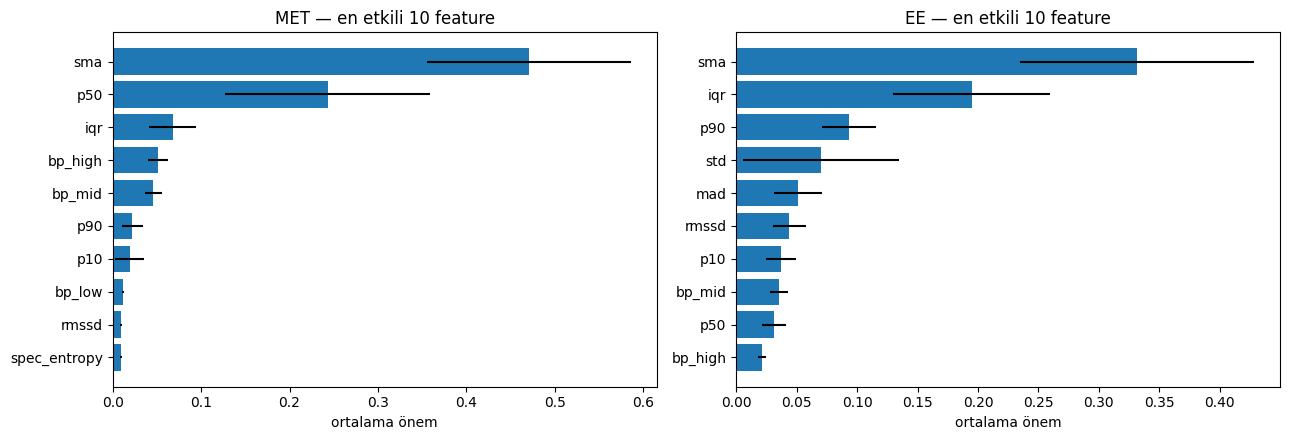

In [33]:
# LOSO fold'ları boyunca ortalanmış feature önemi (fold-içi, sızıntısız)
def loso_importance(d, target, model_fn):
    d=d.dropna(subset=[target]).reset_index(drop=True); cols=feat_cols(d); imps=[]
    for tr,te in LeaveOneGroupOut().split(d[cols],d[target],d['subject']):
        m=model_fn(); m.fit(d[cols].iloc[tr], d[target].iloc[tr])
        if hasattr(m,'feature_importances_'): imps.append(m.feature_importances_)
    if not imps: return None
    I=np.vstack(imps)
    return (pd.DataFrame({'feature':cols,'onem':I.mean(0),'std':I.std(0)})
              .sort_values('onem',ascending=False).reset_index(drop=True))

fig,axes=plt.subplots(1,2,figsize=(13,4.5))
for ax,tgt in zip(axes,['MET','EE']):
    imp=loso_importance(DEVICES['Zephyr_gogus'], tgt, ALL_MODELS()['RandomForest'])
    print(f"=== {tgt} — feature önemi (Zephyr, {BEST_WIN} sn, LOSO ortalaması) ===")
    print(imp.head(10).round(4).to_string(index=False), "\n")
    top=imp.head(10)[::-1]
    ax.barh(top['feature'], top['onem'], xerr=top['std'])
    ax.set_xlabel('ortalama önem'); ax.set_title(f'{tgt} — en etkili 10 feature')
plt.tight_layout(); plt.show()

## B2. İki aşamalı (branched / hierarchical) model *(≈35 dk)*


In [34]:
ZOO_B=['RandomForest','GradientBoosting','XGBoost']
def zoo_for(t,target):
    z=model_zoo(int(t[target].notna().sum()))
    return z if ZOO_B is None else {k:v for k,v in z.items() if k in ZOO_B}

t0=time.time(); rows=[]
for dev,t in DEVICES.items():
    for tgt in ['MET','EE']:
        for name,fn in zoo_for(t,tgt).items():
            rows.append(dict(hedef=tgt,asama='1-tek',**R(name,dev,loso_single(t,tgt,fn))))
            b=loso_twostage(t,tgt,fn)
            rows.append(dict(hedef=tgt,asama='2-iki(tahmin)',clf_acc=b['clf_acc'],**R(name,dev,b)))
            c=loso_twostage(t,tgt,fn,oracle=True)
            rows.append(dict(hedef=tgt,asama='3-iki(bilinen)',**R(name,dev,c)))
    print(f"  {dev} tamam ({time.time()-t0:.0f} sn)")
twoT=pd.DataFrame(rows)
print(f"\n=== B2 · iki aşamalı model ({BEST_WIN} sn) ===")
for tgt in ['MET','EE']:
    print(f"\n--- {tgt} — model × aşama ortalaması (MAE) ---")
    print(twoT[twoT.hedef==tgt].pivot_table(index='model',columns='asama',values='MAE').round(3).to_string())
print("\naşama ortalaması (MAE):")
print(twoT.pivot_table(index='asama',columns='hedef',values='MAE').round(3).to_string())
print("\nsınıflandırma doğruluğu (ortalama):",round(twoT['clf_acc'].dropna().mean(),3))
print("\nEn iyi 10:")
print(twoT.sort_values('MAE').head(10)[['hedef','asama','cihaz','model','MAE','R2','Spearman']].to_string(index=False))

  E4_bilek tamam (960 sn)
  Zephyr_gogus tamam (1887 sn)
  Muse_kafa tamam (2616 sn)

=== B2 · iki aşamalı model (60 sn) ===

--- MET — model × aşama ortalaması (MAE) ---
asama             1-tek  2-iki(tahmin)  3-iki(bilinen)
model                                                 
GradientBoosting  1.757          1.629           1.332
RandomForest      1.797          1.581           1.258
XGBoost           1.698          1.558           1.236

--- EE — model × aşama ortalaması (MAE) ---
asama             1-tek  2-iki(tahmin)  3-iki(bilinen)
model                                                 
GradientBoosting  0.939          0.913           1.017
RandomForest      0.948          0.931           1.018
XGBoost           0.931          0.944           1.049

aşama ortalaması (MAE):
hedef              EE    MET
asama                       
1-tek           0.939  1.751
2-iki(tahmin)   0.929  1.589
3-iki(bilinen)  1.028  1.275

sınıflandırma doğruluğu (ortalama): 0.623

En iyi 10:
hedef    

## B2b. Sınıflandırma teşhisi — MET'in tavanı nerede? *(hızlı)*


In [35]:
dev_best=twoT[twoT.hedef=='MET'].sort_values('MAE').iloc[0]['cihaz']
t=DEVICES[dev_best]; cols=feat_cols(t)
yt_,yp_,sb_,ac_=[],[],[],[]
for tr,te in LeaveOneGroupOut().split(t[cols],t['activity'],t['subject']):
    c=CLF(); c.fit(t[cols].iloc[tr],t['activity'].iloc[tr])
    yp_.extend(c.predict(t[cols].iloc[te])); yt_.extend(t['activity'].iloc[te])
    sb_.extend(t['subject'].iloc[te]); ac_.extend(t['activity'].iloc[te])
res=pd.DataFrame({'subject':sb_,'true':yt_,'pred':yp_})
print(f"=== B2b · aktivite sınıflandırma ({dev_best}, {BEST_WIN} sn) ===")
print("pencere bazında doğruluk:",round(accuracy_score(res['true'],res['pred']),3))
cm=confusion_matrix(res['true'],res['pred'],labels=ACT_ORDER)
print("\nkarışıklık matrisi (satır=gerçek, sütun=tahmin):")
print(pd.DataFrame(cm,index=ACT_ORDER,columns=ACT_ORDER).to_string())
print("\nsınıf bazında doğruluk:")
print((pd.Series(np.diag(cm)/cm.sum(1),index=ACT_ORDER)).round(3).to_string())
maj=(res.groupby(['subject','true'])['pred']
       .agg(lambda s:s.value_counts().idxmax()).reset_index())
print("\nsegment bazında (çoğunluk oyu) doğruluk:",round(accuracy_score(maj['true'],maj['pred']),3))
print("→ Bu değer, class-known üst sınırına ne kadar yaklaşılabileceğini gösterir.")

=== B2b · aktivite sınıflandırma (Muse_kafa, 60 sn) ===
pencere bazında doğruluk: 0.626

karışıklık matrisi (satır=gerçek, sütun=tahmin):
        Sit  Stand  Cycle1  Cycle2  Run1  Run2
Sit     102     32       0       0     1     0
Stand    55     59       2       0     3     0
Cycle1    1      3      89      25     1     0
Cycle2    0      1      38      68     9     3
Run1      0      1       4      13    56    30
Run2      0      1       1       7    29    62

sınıf bazında doğruluk:
Sit       0.756
Stand     0.496
Cycle1    0.748
Cycle2    0.571
Run1      0.538
Run2      0.620

segment bazında (çoğunluk oyu) doğruluk: 0.634
→ Bu değer, class-known üst sınırına ne kadar yaklaşılabileceğini gösterir.


## B3. Vücut kütlesinin **doğru** eklenmesi (yalnız EE) *(≈46 dk)*


In [36]:
VARIANTS={'A) yalniz ivme'    :dict(extra=(),norm=None),
          'B) +ham demografik':dict(extra=('Weight','Height','BMI','Age','Sex'),norm=None),
          'C) +FFM feature'   :dict(extra=('FFM',),norm=None),
          'D) hedef/Weight'   :dict(extra=(),norm='Weight'),
          'E) hedef/FFM'      :dict(extra=(),norm='FFM')}
t0=time.time(); rows=[]
for dev,t in DEVICES.items():
    for vn,cfg in VARIANTS.items():
        for name,fn in zoo_for(t,'EE').items():
            rows.append(dict(varyant=vn,asama='tek',**R(name,dev,
                loso_single(t,'EE',fn,extra=cfg['extra'],norm_col=cfg['norm']))))
            rows.append(dict(varyant=vn,asama='iki',**R(name,dev,
                loso_twostage(t,'EE',fn,extra=cfg['extra'],norm_col=cfg['norm']))))
    print(f"  {dev} tamam ({time.time()-t0:.0f} sn)")
massT=pd.DataFrame(rows)
print(f"\n=== B3 · EE'ye vücut kütlesi ({BEST_WIN} sn) ===")
print("\nvaryant × aşama ortalaması (MAE, düşük iyi):")
print(massT.pivot_table(index='varyant',columns='asama',values='MAE').round(3).to_string())
print("\nvaryant × model ortalaması (MAE):")
print(massT.pivot_table(index='varyant',columns='model',values='MAE').round(3).to_string())
print("\nEn iyi 10:")
print(massT.sort_values('MAE').head(10)[['varyant','asama','cihaz','model','MAE','R2','Spearman']].to_string(index=False))

  E4_bilek tamam (1501 sn)
  Zephyr_gogus tamam (2948 sn)
  Muse_kafa tamam (4107 sn)

=== B3 · EE'ye vücut kütlesi (60 sn) ===

varyant × aşama ortalaması (MAE, düşük iyi):
asama                 iki    tek
varyant                         
A) yalniz ivme      0.929  0.939
B) +ham demografik  0.904  0.972
C) +FFM feature     0.901  0.972
D) hedef/Weight     0.915  0.918
E) hedef/FFM        0.933  0.945

varyant × model ortalaması (MAE):
model               GradientBoosting  RandomForest  XGBoost
varyant                                                    
A) yalniz ivme                 0.926         0.939    0.938
B) +ham demografik             0.933         0.945    0.936
C) +FFM feature                0.945         0.930    0.934
D) hedef/Weight                0.911         0.917    0.922
E) hedef/FFM                   0.922         0.943    0.953

En iyi 10:
           varyant asama     cihaz            model   MAE    R2  Spearman
   D) hedef/Weight   iki Muse_kafa GradientBoosting 0.

### B3 sonrası en iyi kurulum — Bland–Altman + bootstrap CI


En iyi (tek aşama): Zephyr_gogus · GradientBoosting · A) yalniz ivme
  MAE=0.867 (%95 CI 0.648–1.094) | baseline=2.331
  bias=+0.069 | %95 LoA=[-2.567,+2.705]


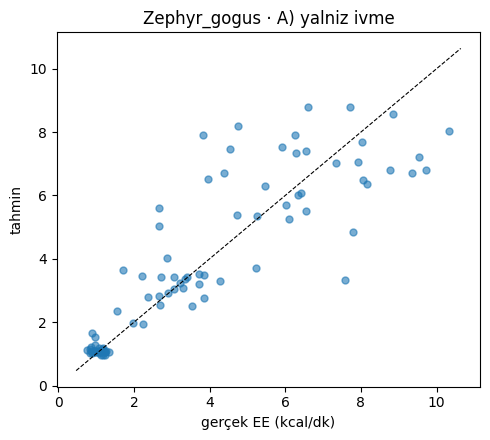


aktivite bazında bias:
           mean    std  count
activity                     
Cycle1    0.085  0.727     15
Cycle2   -0.132  1.263     15
Run1     -0.008  2.329     14
Run2      0.338  2.067     14
Sit       0.113  0.212     16
Stand     0.030  0.267     15


In [37]:
b=massT[massT.asama=='tek'].sort_values('MAE').iloc[0]; cfg=VARIANTS[b['varyant']]
ov,d,yh=loso_single(DEVICES[b['cihaz']],'EE',ALL_MODELS()[b['model']],
                    extra=cfg['extra'],norm_col=cfg['norm'],return_pred=True)
seg,_=seg_frame(d['subject'],d['activity'],d['EE'].values,yh)
lo,hi=bootstrap_ci(seg); diff=seg['p']-seg['y']; bias=diff.mean(); sd=diff.std(ddof=1)
print(f"En iyi (tek aşama): {b['cihaz']} · {b['model']} · {b['varyant']}")
print(f"  MAE={ov['MAE']:.3f} (%95 CI {lo:.3f}–{hi:.3f}) | baseline={ov['MAE_base']:.3f}")
print(f"  bias={bias:+.3f} | %95 LoA=[{bias-1.96*sd:+.3f},{bias+1.96*sd:+.3f}]")
plt.figure(figsize=(5,4.5)); plt.scatter(seg['y'],seg['p'],s=25,alpha=.6)
L=[seg['y'].min()-.3,seg['y'].max()+.3]; plt.plot(L,L,'k--',lw=.8)
plt.xlabel('gerçek EE (kcal/dk)'); plt.ylabel('tahmin'); plt.title(f"{b['cihaz']} · {b['varyant']}")
plt.tight_layout(); plt.show()
print("\naktivite bazında bias:")
print(seg.assign(f=seg['p']-seg['y']).groupby('activity')['f'].agg(['mean','std','count']).round(3).to_string())

### Checkpoint — B4 için T4'e geçmeden **önce** çalıştırın


In [38]:
import pickle
CKPT='/content/drive/MyDrive/PAWS/ckpt'; os.makedirs(CKPT,exist_ok=True)
state=dict(EE_MAP=EE_MAP,DATA_ROOT=DATA_ROOT,BEST_WIN=BEST_WIN,DEMO=DEMO,WIN_A=WIN_A,
           FEATURE_SET=FEATURE_SET)
for nm in ['metA','eeA','fsT','winT','twoT','massT']:
    if nm in globals(): state[nm]=globals()[nm]
with open(f'{CKPT}/state.pkl','wb') as f: pickle.dump(state,f)
for k,v in DEVICES.items(): v.to_pickle(f'{CKPT}/{k}.pkl')
print("kaydedildi →",CKPT,"| içerik:",list(state))

kaydedildi → /content/drive/MyDrive/PAWS/ckpt | içerik: ['EE_MAP', 'DATA_ROOT', 'BEST_WIN', 'DEMO', 'WIN_A', 'FEATURE_SET', 'metA', 'eeA', 'fsT', 'winT', 'twoT', 'massT']


## B4. 1D CNN (ham 3 eksen + FFM) — danışmanın "next step"i


In [39]:
import pickle
CKPT='/content/drive/MyDrive/PAWS/ckpt'
if 'BEST_WIN' not in globals():
    with open(f'{CKPT}/state.pkl','rb') as f: st=pickle.load(f)
    globals().update(st)
    DEVICES={k:pd.read_pickle(f'{CKPT}/{k}.pkl') for k in ['E4_bilek','Zephyr_gogus','Muse_kafa']}
    print("checkpoint yüklendi | pencere:",BEST_WIN)
else:
    print("oturum canlı | pencere:",BEST_WIN)

oturum canlı | pencere: 60


In [40]:
import tensorflow as tf
gpus=tf.config.list_physical_devices('GPU')
print("GPU:",gpus if gpus else "YOK")
if not gpus:
    print("\nUYARI: GPU kapalı. B4 CPU'da çok uzun sürer (fold başına dakikalar).")
    print("Runtime → Change runtime type → T4 GPU seçip bu hücreden devam edin,")
    print("veya B4'ü atlayın (küçük veride CNN'in ağaç modellerini geçmesi beklenmez).")

GPU: YOK

UYARI: GPU kapalı. B4 CPU'da çok uzun sürer (fold başına dakikalar).
Runtime → Change runtime type → T4 GPU seçip bu hücreden devam edin,
veya B4'ü atlayın (küçük veride CNN'in ağaç modellerini geçmesi beklenmez).


In [41]:
DEVICE_CNN='E4'; L_CNN=256
def resample_fixed(w,L):
    n=len(w)
    if n==L: return w
    o=np.linspace(0,1,n); q=np.linspace(0,1,L)
    return np.stack([np.interp(q,o,w[:,c]) for c in range(w.shape[1])],axis=1).astype(np.float32)
def build_windows(kind,win_sec):
    X=[];ym=[];ye=[];sb=[];ac=[]
    for pid,xb,yb,zb,mbp,mraw,fs,tt in get_signals(kind):
        r=SI[SI['Participant']==pid].iloc[0]
        for s in activity_segments(r):
            if not s['valid']: continue
            m=(tt>=s['start'])&(tt<s['end'])
            wx,wy,wz=(segment_signal(v[m],fs,win_sec) for v in (xb,yb,zb))
            for a,b_,c_ in zip(wx,wy,wz):
                if len(a)<8: continue
                X.append(resample_fixed(np.stack([a,b_,c_],axis=1),L_CNN))
                ym.append(s['MET']); ye.append(EE_MAP.get((pid,s['activity']),np.nan))
                sb.append(pid); ac.append(s['activity'])
    return (np.array(X,np.float32),np.array(ym,np.float32),np.array(ye,np.float32),
            np.array(sb),np.array(ac))
Xw,ymet_w,yee_w,subs_w,acts_w=build_windows(DEVICE_CNN,BEST_WIN)
ffm_w=np.array([[DEMO.loc[p,'FFM']] for p in subs_w],np.float32)
print(f"{DEVICE_CNN} @ {BEST_WIN}sn → {Xw.shape} | özne {len(set(subs_w))} | NaN {int(np.isnan(Xw).sum())}")

E4 @ 60sn → (833, 256, 3) | özne 17 | NaN 0


In [42]:
from tensorflow.keras import layers, models, callbacks
def build_cnn(L,ch,nd):
    sig=layers.Input((L,ch))
    h=layers.Conv1D(32,7,padding='same',activation='relu')(sig); h=layers.BatchNormalization()(h); h=layers.MaxPool1D(2)(h)
    h=layers.Conv1D(64,5,padding='same',activation='relu')(h);   h=layers.BatchNormalization()(h); h=layers.MaxPool1D(2)(h)
    h=layers.Conv1D(64,3,padding='same',activation='relu')(h);   h=layers.GlobalAveragePooling1D()(h)
    dem=layers.Input((nd,)); h=layers.Concatenate()([h,dem])
    h=layers.Dense(64,activation='relu')(h); h=layers.Dropout(0.3)(h)
    m=models.Model([sig,dem],layers.Dense(1)(h)); m.compile('adam','mse'); return m
def loso_cnn(X,y,subs,acts,dem,norm_vec=None,epochs=60,batch=64):
    keep=~np.isnan(y); X,y,subs,acts,dem=X[keep],y[keep],subs[keep],acts[keep],dem[keep]
    nv=norm_vec[keep] if norm_vec is not None else None
    yt=y/nv if nv is not None else y
    yh=np.full(len(y),np.nan); yb=np.full(len(y),np.nan)
    for tr,te in LeaveOneGroupOut().split(X,yt,subs):
        yb[te]=y[tr].mean()                                    # fold-içi baseline
        mu=X[tr].mean((0,1),keepdims=True); sd=X[tr].std((0,1),keepdims=True)+1e-6
        dmu=dem[tr].mean(0); dsd=dem[tr].std(0)+1e-6
        tf.keras.backend.clear_session()
        m=build_cnn(X.shape[1],X.shape[2],dem.shape[1])
        es=callbacks.EarlyStopping(monitor='loss',patience=8,restore_best_weights=True)
        m.fit([(X[tr]-mu)/sd,(dem[tr]-dmu)/dsd],yt[tr],epochs=epochs,batch_size=batch,
              verbose=0,callbacks=[es])
        p=m.predict([(X[te]-mu)/sd,(dem[te]-dmu)/dsd],verbose=0).ravel()
        yh[te]=p*nv[te] if nv is not None else p
    return seg_metrics(subs,acts,y,yh,yb)
print("CNN tanımları hazır")

CNN tanımları hazır


In [43]:
t0=time.time(); rows=[]
for tgt,yv,nv,lbl in [('MET',ymet_w,None,'1D-CNN (+FFM girdi)'),
                      ('EE', yee_w, None,'1D-CNN (+FFM girdi)'),
                      ('EE', yee_w, ffm_w.ravel(),'1D-CNN (hedef/FFM)')]:
    ov=loso_cnn(Xw,yv,subs_w,acts_w,ffm_w,norm_vec=nv)
    rows.append(dict(hedef=tgt,model=lbl,**{k:round(ov[k],3) for k in ['MAE','RMSE','R2','Spearman']},
                     MAE_base=round(ov['MAE_base'],3),n=ov['n'],subj=ov['subj']))
    print(f"  {tgt} · {lbl} tamam ({time.time()-t0:.0f} sn)")
cnnT=pd.DataFrame(rows)
print(f"\n=== B4 · 1D CNN ({DEVICE_CNN}, {BEST_WIN} sn) ===")
print(cnnT.to_string(index=False))

  MET · 1D-CNN (+FFM girdi) tamam (648 sn)
  EE · 1D-CNN (+FFM girdi) tamam (1312 sn)
  EE · 1D-CNN (hedef/FFM) tamam (2130 sn)

=== B4 · 1D CNN (E4, 60 sn) ===
hedef               model   MAE  RMSE    R2  Spearman  MAE_base  n  subj
  MET 1D-CNN (+FFM girdi) 3.548 4.519 0.460     0.654     5.449 95    17
   EE 1D-CNN (+FFM girdi) 1.378 1.766 0.579     0.843     2.331 89    16
   EE  1D-CNN (hedef/FFM) 1.249 1.714 0.604     0.830     2.331 89    16


# Özet — bütün adımlar tek tabloda


In [44]:
S=[]
def add(h,ad,v):
    if v==v: S.append(dict(hedef=h,adim=ad,MAE=round(float(v),3)))
for tgt,baseT in [('MET',metA),('EE',eeA)]:
    add(tgt,f'A) cekirdek ({WIN_A} sn, {FEATURE_SET})',baseT['MAE'].min())
    try: add(tgt,f'B1) pencere {BEST_WIN} sn',winT[(winT.hedef==tgt)&(winT.pencere==BEST_WIN)]['MAE'].min())
    except Exception: pass
    try: add(tgt,'B2) tek asama (tam havuz)',twoT[(twoT.hedef==tgt)&(twoT.asama=='1-tek')]['MAE'].min())
    except Exception: pass
    try: add(tgt,'B2) iki asama (class-estimated)',twoT[(twoT.hedef==tgt)&(twoT.asama=='2-iki(tahmin)')]['MAE'].min())
    except Exception: pass
    try: add(tgt,'B2) iki asama (class-known, ust sinir)',twoT[(twoT.hedef==tgt)&(twoT.asama=='3-iki(bilinen)')]['MAE'].min())
    except Exception: pass
    if tgt=='EE':
        try: add(tgt,'B3) en iyi kutle varyanti',massT['MAE'].min())
        except Exception: pass
    try: add(tgt,'B4) 1D CNN',cnnT[cnnT.hedef==tgt]['MAE'].min())
    except Exception: pass
print(pd.DataFrame(S).to_string(index=False))
print("\nHer satır o adımdaki EN İYİ cihaz/model kombinasyonudur.")
try:
    print("\nB0 — feature setinin etkisi (MAE ortalaması):")
    print(fsT.pivot_table(index='fset',columns='hedef',values='MAE').round(3).to_string())
except Exception: pass

hedef                                   adim   MAE
  MET             A) cekirdek (4 sn, zengin) 1.888
  MET                      B1) pencere 60 sn 1.488
  MET              B2) tek asama (tam havuz) 1.488
  MET        B2) iki asama (class-estimated) 1.368
  MET B2) iki asama (class-known, ust sinir) 1.080
  MET                             B4) 1D CNN 3.548
   EE             A) cekirdek (4 sn, zengin) 0.883
   EE                      B1) pencere 60 sn 0.884
   EE              B2) tek asama (tam havuz) 0.867
   EE        B2) iki asama (class-estimated) 0.837
   EE B2) iki asama (class-known, ust sinir) 0.907
   EE              B3) en iyi kutle varyanti 0.818
   EE                             B4) 1D CNN 1.249

Her satır o adımdaki EN İYİ cihaz/model kombinasyonudur.

B0 — feature setinin etkisi (MAE ortalaması):
hedef        EE    MET
fset                  
eski      0.986  2.246
simetrik  0.978  2.010
zengin    0.951  1.949


## Sınırlar ve yorum notları
